In [1]:
%pip install pytorch_lightning

import os, random, math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import display

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, ConcatDataset, random_split
import torchvision.transforms as T

import pytorch_lightning as pl
from sklearn.metrics import roc_auc_score, confusion_matrix

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
IMG_SIZE = 70
INPUT_DIM = IMG_SIZE * IMG_SIZE
print(f'Device: {DEVICE}')


Device: cpu


## Wczytywanie danych Pythia

In [2]:
DATA_ROOT = Path('../Pythia')
ATTACK_NAMES = ['attack_a', 'attack_b', 'attack_c', 'attack_d',
                'attack_e', 'attack_f', 'attack_g', 'attack_h']

transform = T.ToTensor()

class PythiaDataset(Dataset):
    """Loads grayscale PNG images from a single folder. Returns (img_tensor, is_poisoned)."""
    def __init__(self, folder, is_poisoned=0, transform=None):
        self.files = sorted(Path(folder).glob('*.png'))
        self.is_poisoned = is_poisoned
        self.transform = transform or T.ToTensor()

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert('L')
        return self.transform(img), self.is_poisoned


clean_ds = PythiaDataset(DATA_ROOT / 'clean', is_poisoned=0, transform=transform)
attack_ds = {
    name: PythiaDataset(DATA_ROOT / name, is_poisoned=1, transform=transform)
    for name in ATTACK_NAMES
}

# Split clean into train/val for autoencoder training
clean_train_size = int(0.8 * len(clean_ds))
clean_val_size = len(clean_ds) - clean_train_size
clean_train, clean_val = random_split(
    clean_ds, [clean_train_size, clean_val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(f'Clean total: {len(clean_ds)} | train: {len(clean_train)} | val: {len(clean_val)}')
for name, ds in attack_ds.items():
    print(f'{name}: {len(ds)} images')

Clean total: 1000 | train: 800 | val: 200
attack_a: 1000 images
attack_b: 1000 images
attack_c: 1000 images
attack_d: 1000 images
attack_e: 1000 images
attack_f: 1000 images
attack_g: 1000 images
attack_h: 1000 images


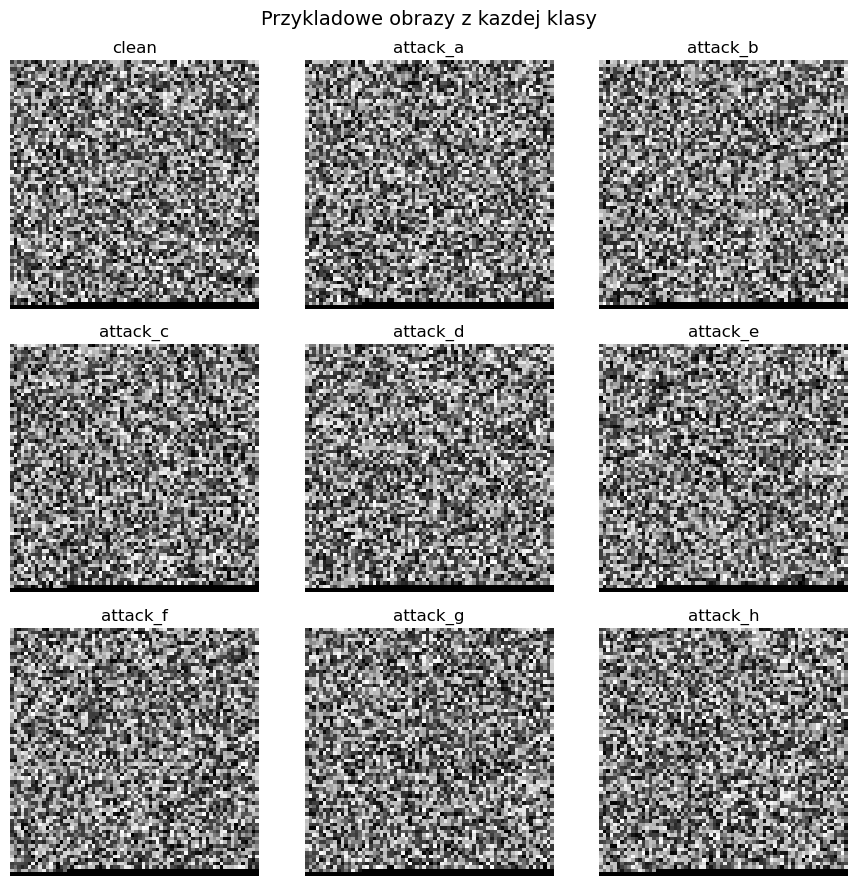

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
all_class_names = ['clean'] + ATTACK_NAMES

for i, name in enumerate(all_class_names):
    ax = axes[i // 3][i % 3]
    ds = clean_ds if name == 'clean' else attack_ds[name]
    img, _ = ds[0]
    ax.imshow(img.squeeze().numpy(), cmap='gray')
    ax.set_title(name)
    ax.axis('off')

plt.suptitle('Przykladowe obrazy z kazdej klasy', fontsize=14)
plt.tight_layout()
plt.show()

## Zadanie 3 - Autoenkoder (Pythia)

In [4]:
class LitAutoEncoder(pl.LightningModule):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=512, latent_dim=128):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )
        self.criterion = nn.MSELoss()

    def forward(self, x):
        batch_size = x.size(0)
        x_flat = x.view(batch_size, -1)
        z = self.encoder(x_flat)
        return self.decoder(z).view(x.shape)

    def training_step(self, batch, batch_idx):
        x = batch[0]
        loss = self.criterion(self(x), x)
        self.log('train_loss', loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x = batch[0]
        loss = self.criterion(self(x), x)
        self.log('val_loss', loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)

In [5]:
# Trening autoenkodera na czystych danych
ae_train_loader = DataLoader(clean_train, batch_size=64, shuffle=True, num_workers=0)
ae_val_loader   = DataLoader(clean_val,   batch_size=64, shuffle=False, num_workers=0)

ae_model = LitAutoEncoder()
ae_trainer = pl.Trainer(
    max_epochs=20,
    accelerator='auto',
    devices=1,
    log_every_n_steps=10,
    enable_model_summary=False,
)
ae_trainer.fit(ae_model, ae_train_loader, ae_val_loader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\woks0\anaconda3\Lib\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automaticall

Output()

c:\Users\woks0\anaconda3\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, 
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

c:\Users\woks0\anaconda3\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

c:\Users\woks0\anaconda3\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=20` reached.


## Wyniki - Autoenkoder (MSE + aurco)

In [6]:
def evaluate_reconstruction(model, loader):
    model.eval()
    model.to(DEVICE)
    criterion = nn.MSELoss(reduction='none')
    losses = []
    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(DEVICE)
            x_hat = model(x)
            loss_per_image = criterion(x_hat, x).view(x.size(0), -1).mean(dim=1)
            losses.extend(loss_per_image.cpu().numpy())
    return np.array(losses)


clean_val_loader = DataLoader(clean_val, batch_size=256, shuffle=False, num_workers=0)
clean_losses = evaluate_reconstruction(ae_model, clean_val_loader)
print(f'Clean val  Mean MSE: {clean_losses.mean():.4f} +/- {clean_losses.std():.4f}')

ae_results = []
for name in ATTACK_NAMES:
    loader = DataLoader(attack_ds[name], batch_size=256, shuffle=False, num_workers=0)
    attack_losses = evaluate_reconstruction(ae_model, loader)

    y_true   = np.concatenate([np.zeros(len(clean_losses)), np.ones(len(attack_losses))])
    y_scores = np.concatenate([clean_losses, attack_losses])
    auc = roc_auc_score(y_true, y_scores)

    print(f'{name}: MSE={attack_losses.mean():.4f} +/- {attack_losses.std():.4f} | AUC={auc:.4f}')
    ae_results.append({
        'Attack': name,
        'Mean MSE': round(attack_losses.mean(), 4),
        'Std MSE':  round(attack_losses.std(),  4),
        'ROC AUC':  round(auc, 4)
    })

ae_results_df = pd.DataFrame(ae_results)
display(ae_results_df.sort_values('ROC AUC', ascending=False))

Clean val  Mean MSE: 0.0762 +/- 0.0010
attack_a: MSE=0.0762 +/- 0.0010 | AUC=0.5087
attack_b: MSE=0.0761 +/- 0.0010 | AUC=0.4938
attack_c: MSE=0.0762 +/- 0.0010 | AUC=0.4954
attack_d: MSE=0.0762 +/- 0.0010 | AUC=0.4974
attack_e: MSE=0.0761 +/- 0.0010 | AUC=0.4766
attack_f: MSE=0.0761 +/- 0.0010 | AUC=0.4805
attack_g: MSE=0.0761 +/- 0.0010 | AUC=0.4703
attack_h: MSE=0.0761 +/- 0.0010 | AUC=0.4945


,Attack,Mean MSE,Std MSE,ROC AUC
0,attack_a,0.0762,0.001,0.5087
3,attack_d,0.0762,0.001,0.4974
2,attack_c,0.0762,0.001,0.4954
7,attack_h,0.0761,0.001,0.4945
1,attack_b,0.0761,0.001,0.4938
5,attack_f,0.0761,0.001,0.4805
4,attack_e,0.0761,0.001,0.4766
6,attack_g,0.0761,0.001,0.4703


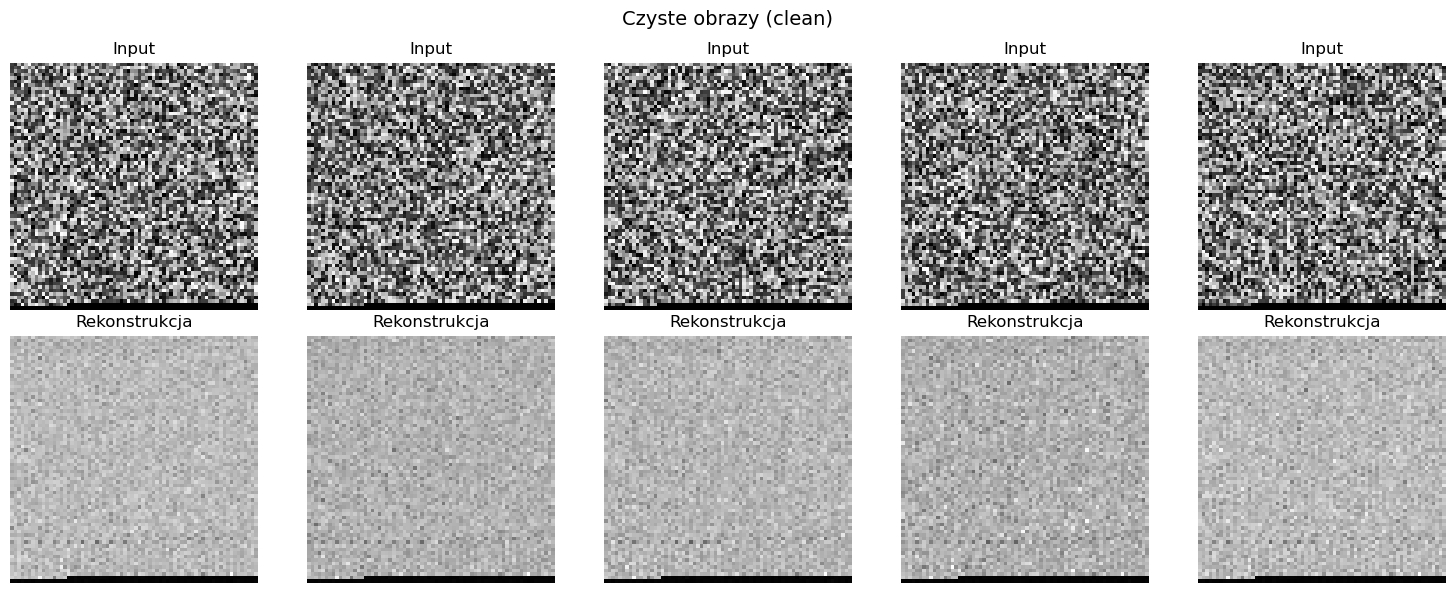

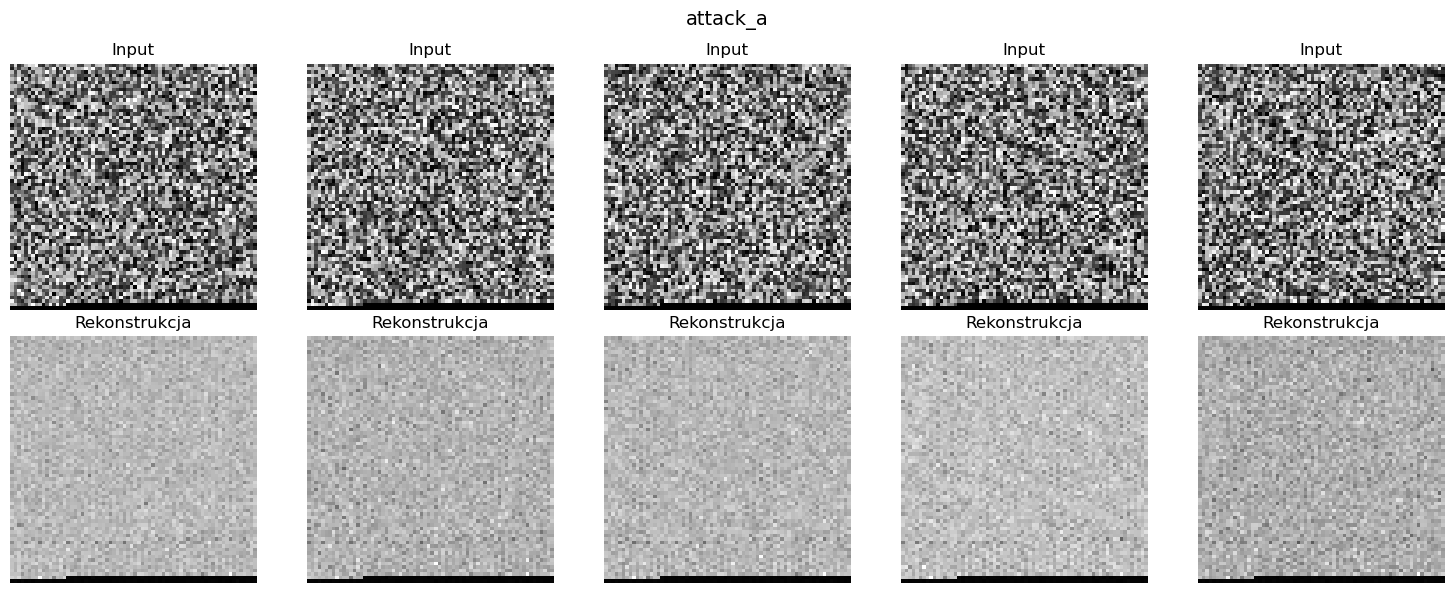

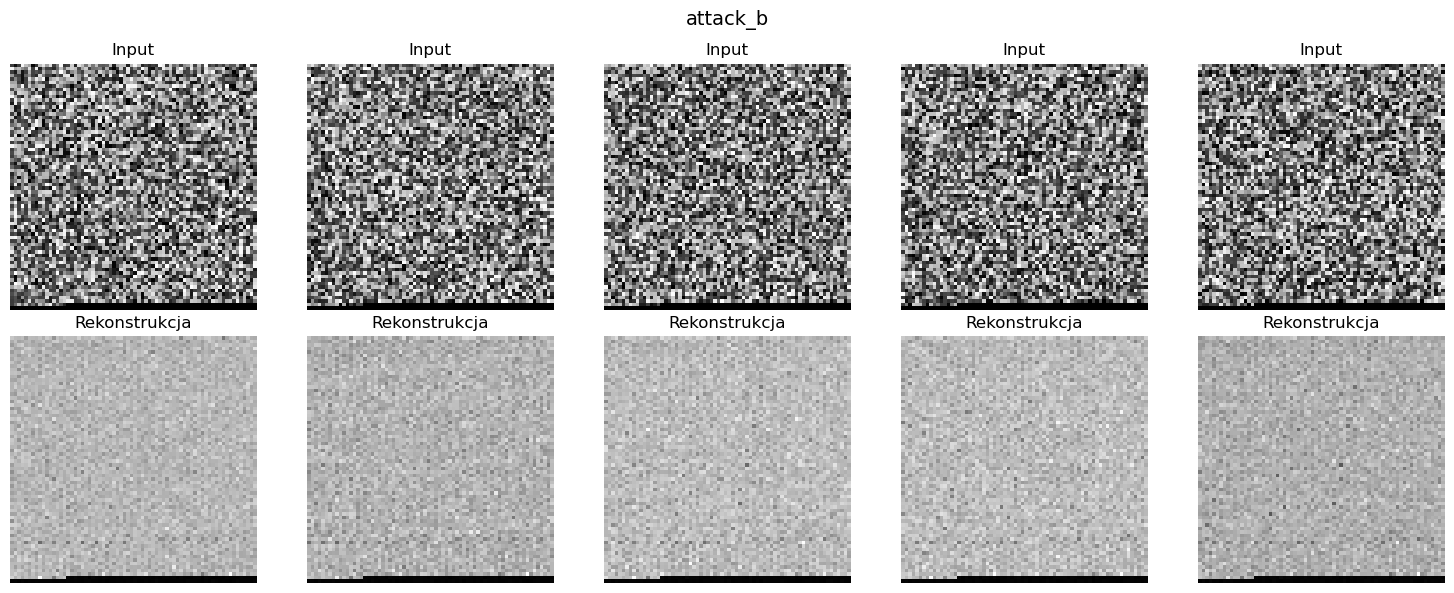

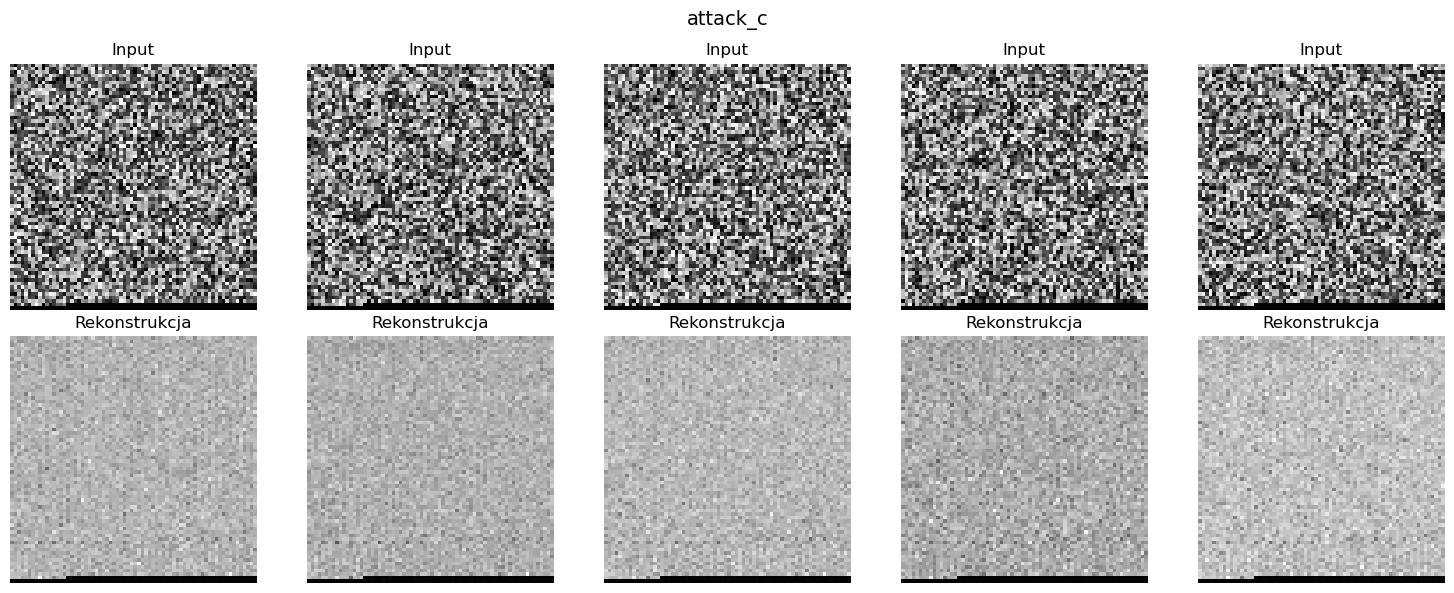

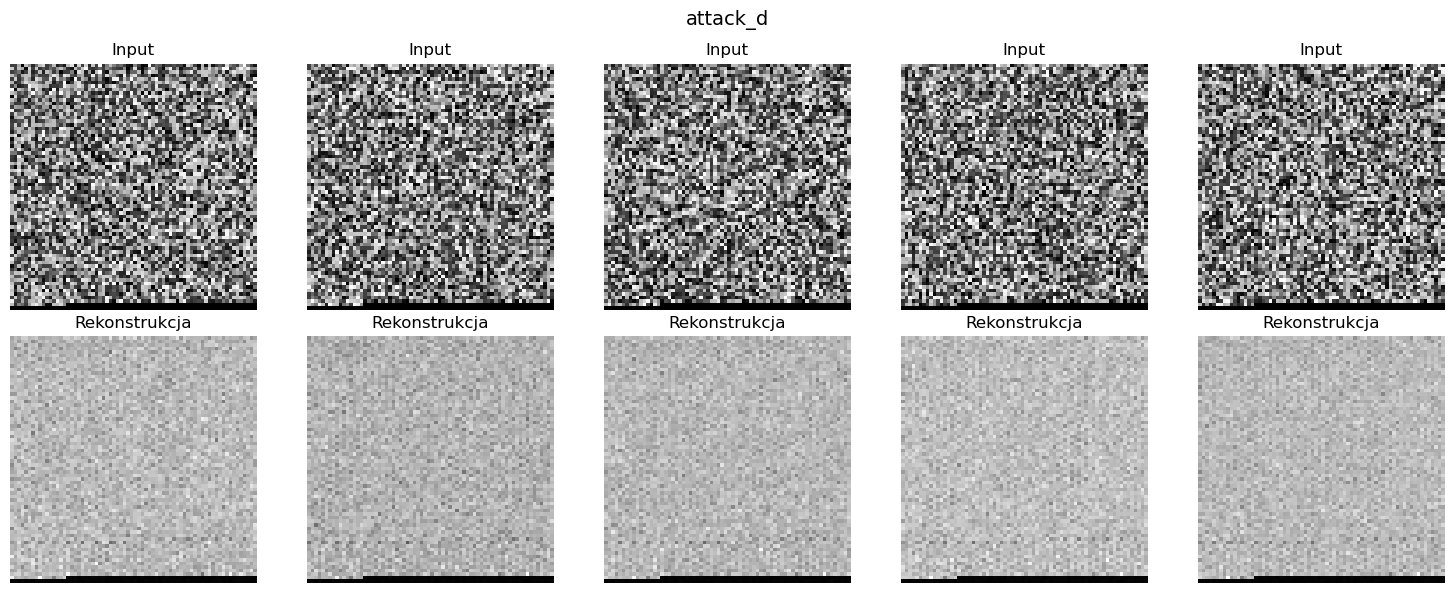

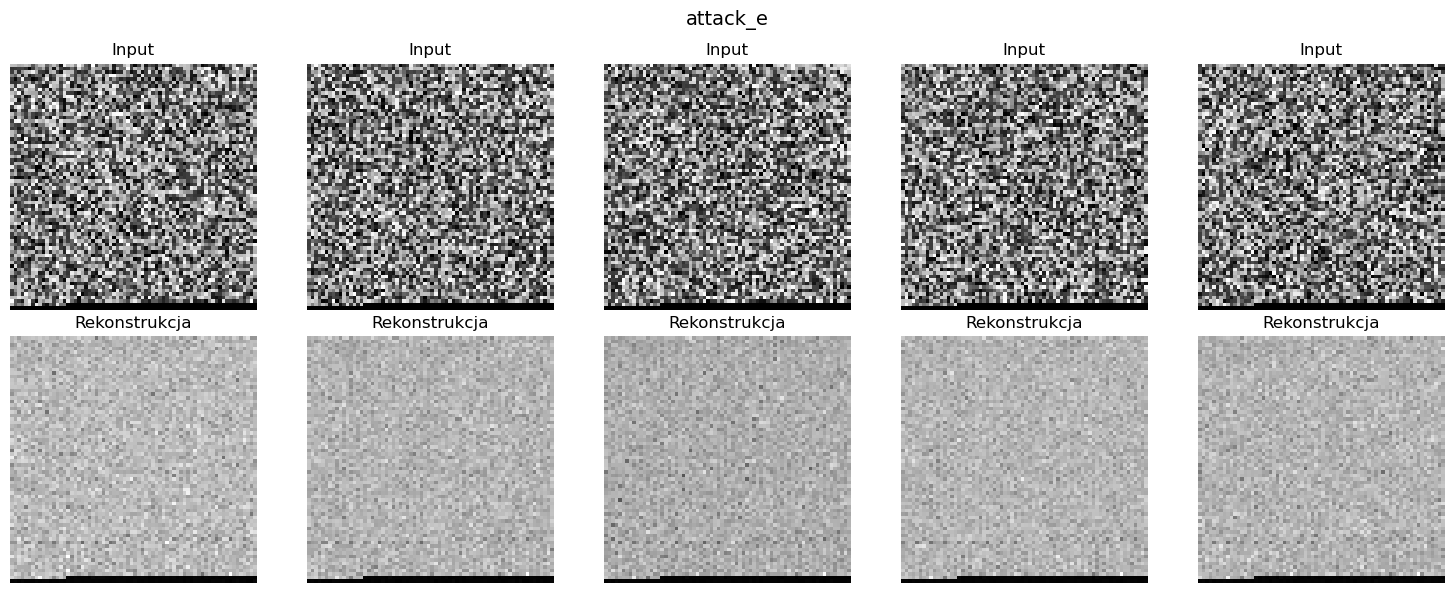

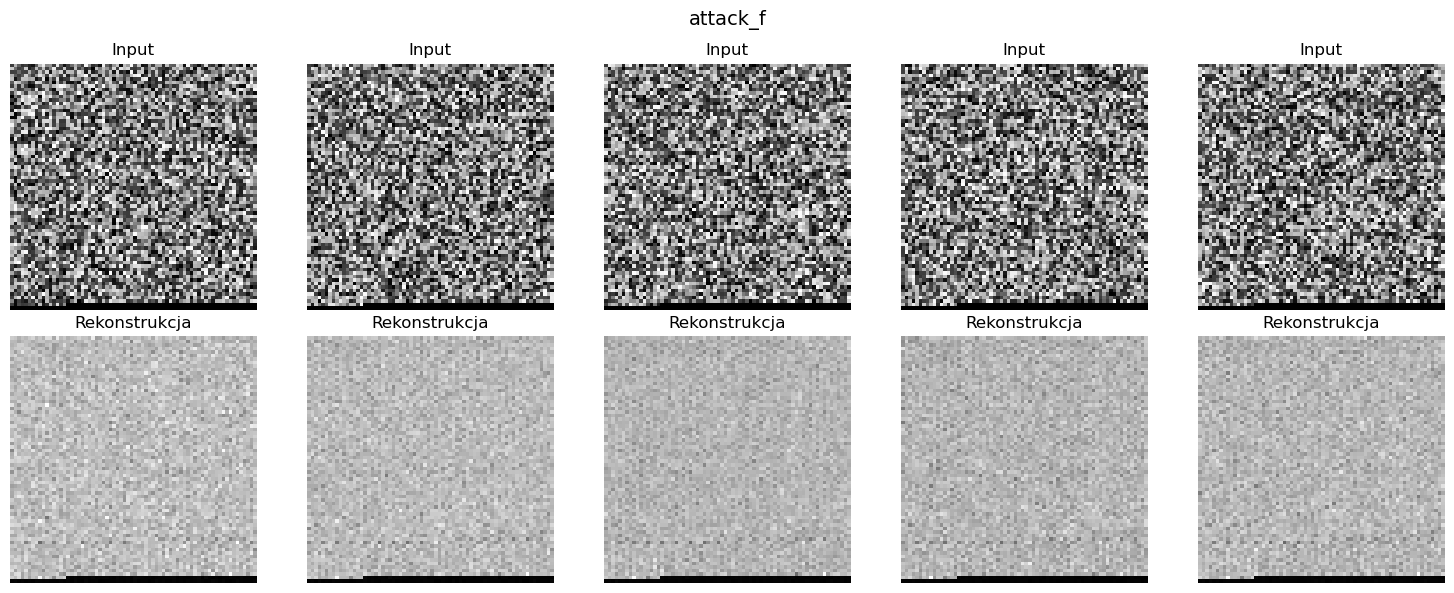

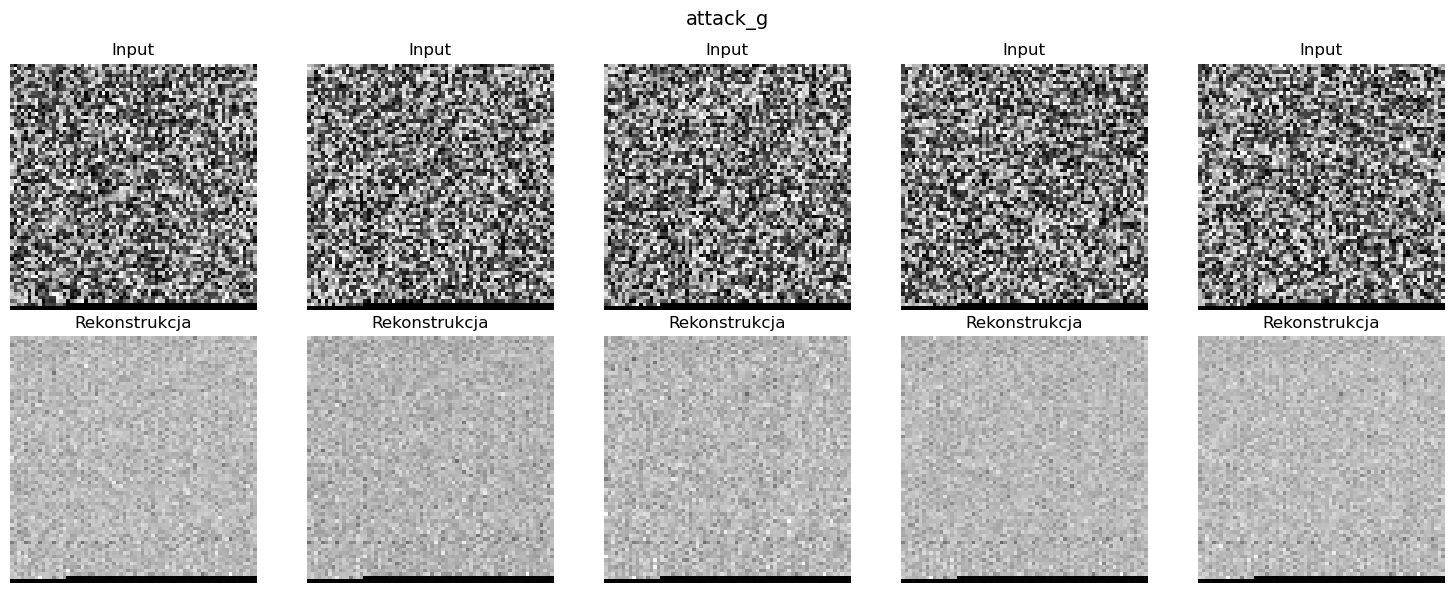

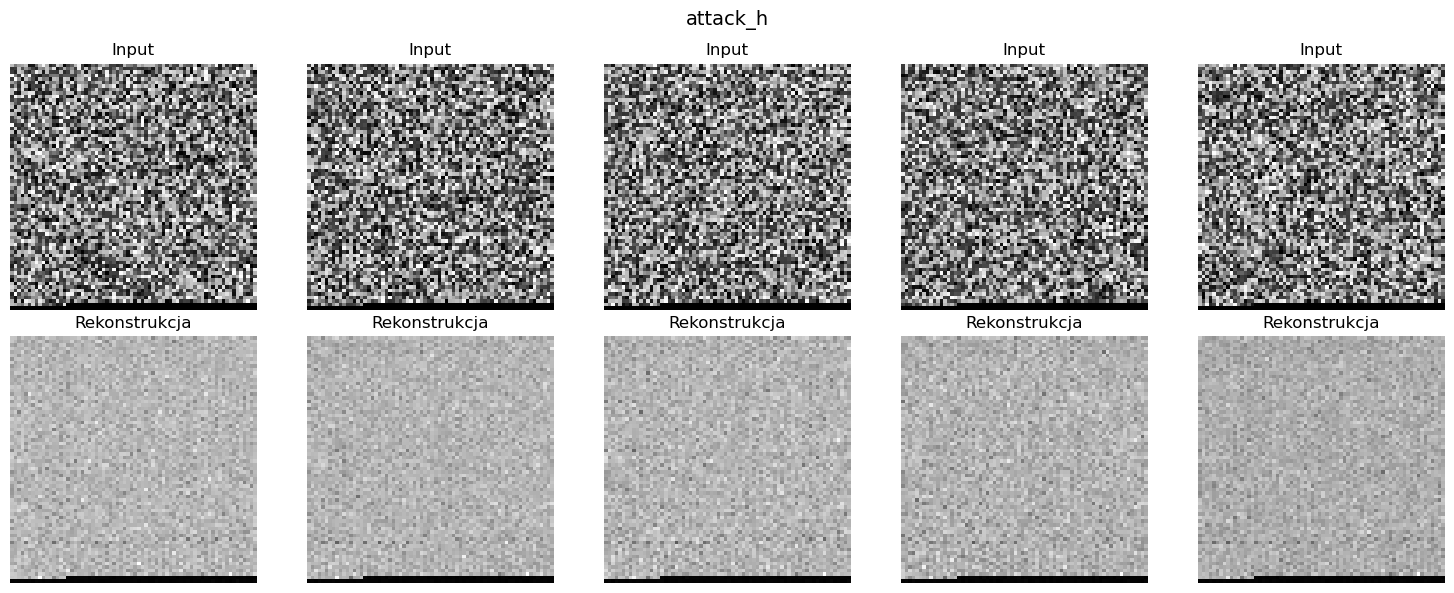

In [7]:
def show_reconstructions(model, dataset, n=5, title=''):
    model.eval()
    model.to(DEVICE)
    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    fig.suptitle(title, fontsize=14)
    indices = np.random.choice(len(dataset), n, replace=False)
    for i, idx in enumerate(indices):
        x = dataset[idx][0].unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            x_hat = model(x)
        axes[0, i].imshow(x.squeeze().cpu().numpy(), cmap='gray')
        axes[0, i].set_title('Input')
        axes[0, i].axis('off')
        axes[1, i].imshow(x_hat.squeeze().cpu().numpy(), cmap='gray')
        axes[1, i].set_title('Rekonstrukcja')
        axes[1, i].axis('off')
    plt.tight_layout()
    plt.show()


show_reconstructions(ae_model, clean_val, title='Czyste obrazy (clean)')
for name in ATTACK_NAMES:
    show_reconstructions(ae_model, attack_ds[name], title=f'{name}')

## Zadanie 4 - Klasyfikator anomalii (enkoder + glowica)

In [8]:
class LitAnomalyClassifier(pl.LightningModule):
    def __init__(self, encoder, fc_in=128, fc_hidden=64, dropout_rate1=0.2, dropout_rate2=0.1):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(fc_in, fc_hidden),
            nn.GELU(),
            nn.Dropout(dropout_rate1),
            nn.Linear(fc_hidden, max(fc_hidden // 2, 16)),
            nn.GELU(),
            nn.Dropout(dropout_rate2),
            nn.Linear(max(fc_hidden // 2, 16), 1),
        )
        self.criterion = nn.BCEWithLogitsLoss()

    def forward(self, x):
        batch_size = x.size(0)
        x_flat = x.view(batch_size, -1)
        z = self.encoder(x_flat)
        return self.classifier(z).view(-1)

    def _step(self, batch, stage):
        x, is_poisoned = batch[0], batch[1].float()
        loss = self.criterion(self(x), is_poisoned)
        self.log(f'{stage}_classifier_loss', loss, prog_bar=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self._step(batch, 'train')

    def validation_step(self, batch, batch_idx):
        return self._step(batch, 'val')

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)

In [ ]:
# Trening jednego klasyfikatora per atak
import copy

os.makedirs('saved_models', exist_ok=True)
clf_models = {}

for attack_name in ATTACK_NAMES:
    print(f'Training classifier for {attack_name}')

    joined_ds = ConcatDataset([clean_ds, attack_ds[attack_name]])
    train_size = int(0.8 * len(joined_ds))
    val_size   = len(joined_ds) - train_size
    train_split, val_split = random_split(
        joined_ds, [train_size, val_size],
        generator=torch.Generator().manual_seed(SEED)
    )

    train_loader = DataLoader(train_split, batch_size=64, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_split,   batch_size=64, shuffle=False, num_workers=0)

    clf = LitAnomalyClassifier(encoder=copy.deepcopy(ae_model.encoder))
    trainer = pl.Trainer(
        max_epochs=10,
        accelerator='auto',
        devices=1,
        log_every_n_steps=10,
        enable_model_summary=False,
    )
    trainer.fit(clf, train_loader, val_loader)
    trainer.save_checkpoint(f'saved_models/clf_{attack_name}.ckpt')
    clf_models[attack_name] = clf

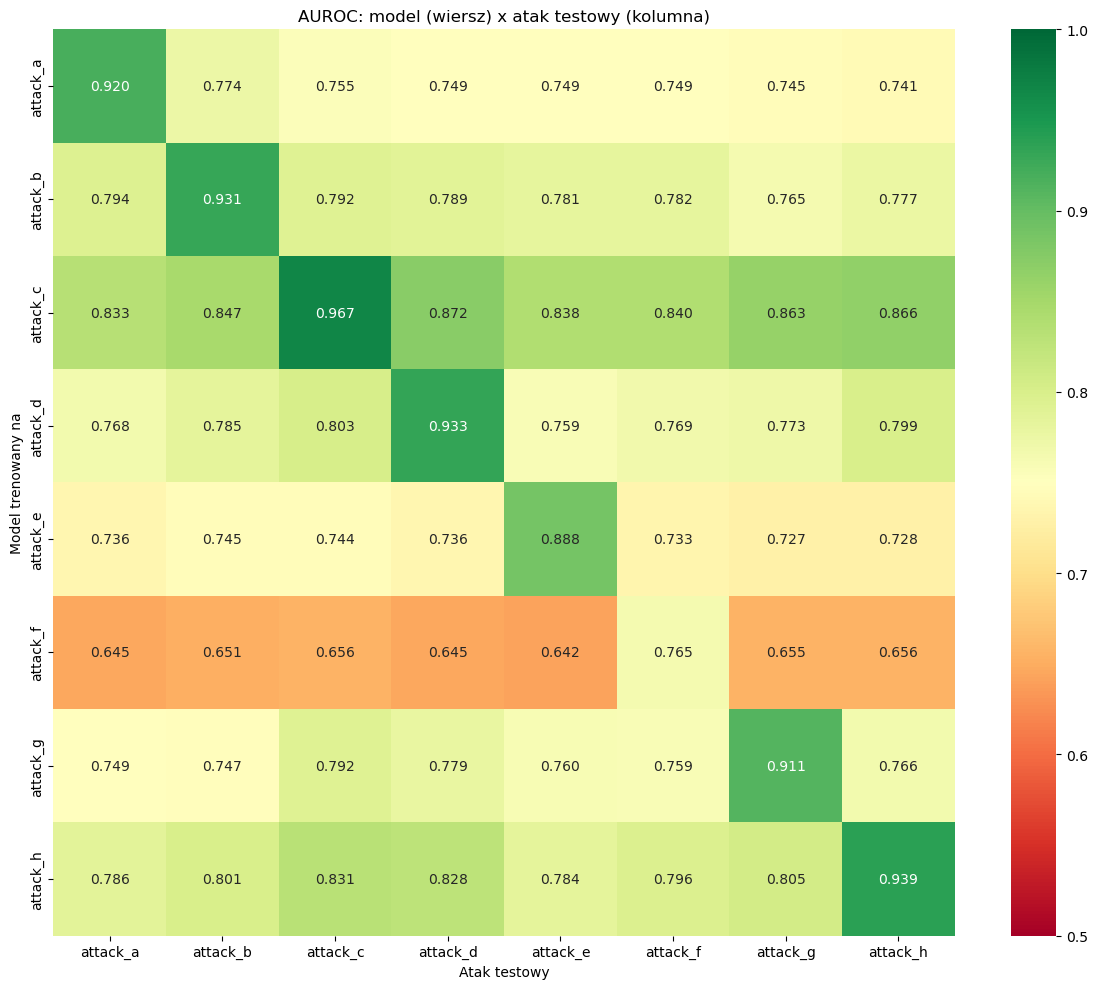

,attack_a,attack_b,attack_c,attack_d,attack_e,attack_f,attack_g,attack_h
attack_a,0.920,0.774,0.755,0.749,0.749,0.749,0.745,0.741
attack_b,0.794,0.931,0.792,0.789,0.781,0.782,0.765,0.777
attack_c,0.833,0.847,0.967,0.872,0.838,0.840,0.863,0.866
attack_d,0.768,0.785,0.803,0.933,0.759,0.769,0.773,0.799
attack_e,0.736,0.745,0.744,0.736,0.888,0.733,0.727,0.728
attack_f,0.645,0.651,0.656,0.645,0.642,0.765,0.655,0.656
attack_g,0.749,0.747,0.792,0.779,0.760,0.759,0.911,0.766
attack_h,0.786,0.801,0.831,0.828,0.784,0.796,0.805,0.939


In [10]:
# AUROC heatmap: model trenowany na (wiersz) x atak testowy (kolumna)
n_attacks = len(ATTACK_NAMES)
auroc_matrix = np.zeros((n_attacks, n_attacks))

for i, (model_name, model) in enumerate(clf_models.items()):
    model.eval()
    for j, test_attack_name in enumerate(ATTACK_NAMES):
        test_ds_j = ConcatDataset([clean_ds, attack_ds[test_attack_name]])
        test_loader = DataLoader(test_ds_j, batch_size=64, shuffle=False, num_workers=0)

        all_scores, all_labels = [], []
        with torch.no_grad():
            for imgs, is_poisoned in test_loader:
                imgs = imgs.to(model.device)
                scores = torch.sigmoid(model(imgs)).cpu()
                all_scores.extend(scores.numpy())
                all_labels.extend(is_poisoned.numpy())

        auroc_matrix[i, j] = roc_auc_score(all_labels, all_scores)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    auroc_matrix,
    annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=0.5, vmax=1.0,
    xticklabels=ATTACK_NAMES,
    yticklabels=ATTACK_NAMES,
    ax=ax
)
ax.set_xlabel('Atak testowy')
ax.set_ylabel('Model trenowany na')
ax.set_title('AUROC: model (wiersz) x atak testowy (kolumna)')
plt.tight_layout()
plt.show()

auroc_df = pd.DataFrame(auroc_matrix, index=ATTACK_NAMES, columns=ATTACK_NAMES)
display(auroc_df.round(3))

## Eksperyment leave-one-out - generalizacja na nieznany atak

In [11]:
mixed_clf_models = {}

for held_out in ATTACK_NAMES:
    train_attacks = [name for name in ATTACK_NAMES if name != held_out]
    print(f'\n--- Held out (unseen): {held_out} | Training on: {train_attacks} ---')

    # Polaczenie: clean + wszystkie ataki poza held_out
    mixed_ds = ConcatDataset([clean_ds] + [attack_ds[name] for name in train_attacks])
    train_size = int(0.8 * len(mixed_ds))
    val_size   = len(mixed_ds) - train_size
    train_split, val_split = random_split(
        mixed_ds, [train_size, val_size],
        generator=torch.Generator().manual_seed(SEED)
    )

    train_loader = DataLoader(train_split, batch_size=64, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_split,   batch_size=64, shuffle=False, num_workers=0)

    clf = LitAnomalyClassifier(encoder=copy.deepcopy(ae_model.encoder))
    trainer = pl.Trainer(
        max_epochs=10,
        accelerator='auto',
        devices=1,
        log_every_n_steps=10,
        enable_model_summary=False,
    )
    trainer.fit(clf, train_loader, val_loader)
    trainer.save_checkpoint(f'saved_models/clf_mixed_no_{held_out}.ckpt')
    mixed_clf_models[held_out] = clf

GPU available: False, used: False



--- Held out (unseen): attack_a | Training on: ['attack_b', 'attack_c', 'attack_d', 'attack_e', 'attack_f', 'attack_g', 'attack_h'] ---


TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Output()

c:\Users\woks0\anaconda3\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, 
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

...


--- Held out (unseen): attack_h | Training on: ['attack_a', 'attack_b', 'attack_c', 'attack_d', 'attack_e', 'attack_f', 'attack_g'] ---


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Output()

`Trainer.fit` stopped: `max_epochs=10` reached.


`weights_only` was not set, defaulting to `False`.


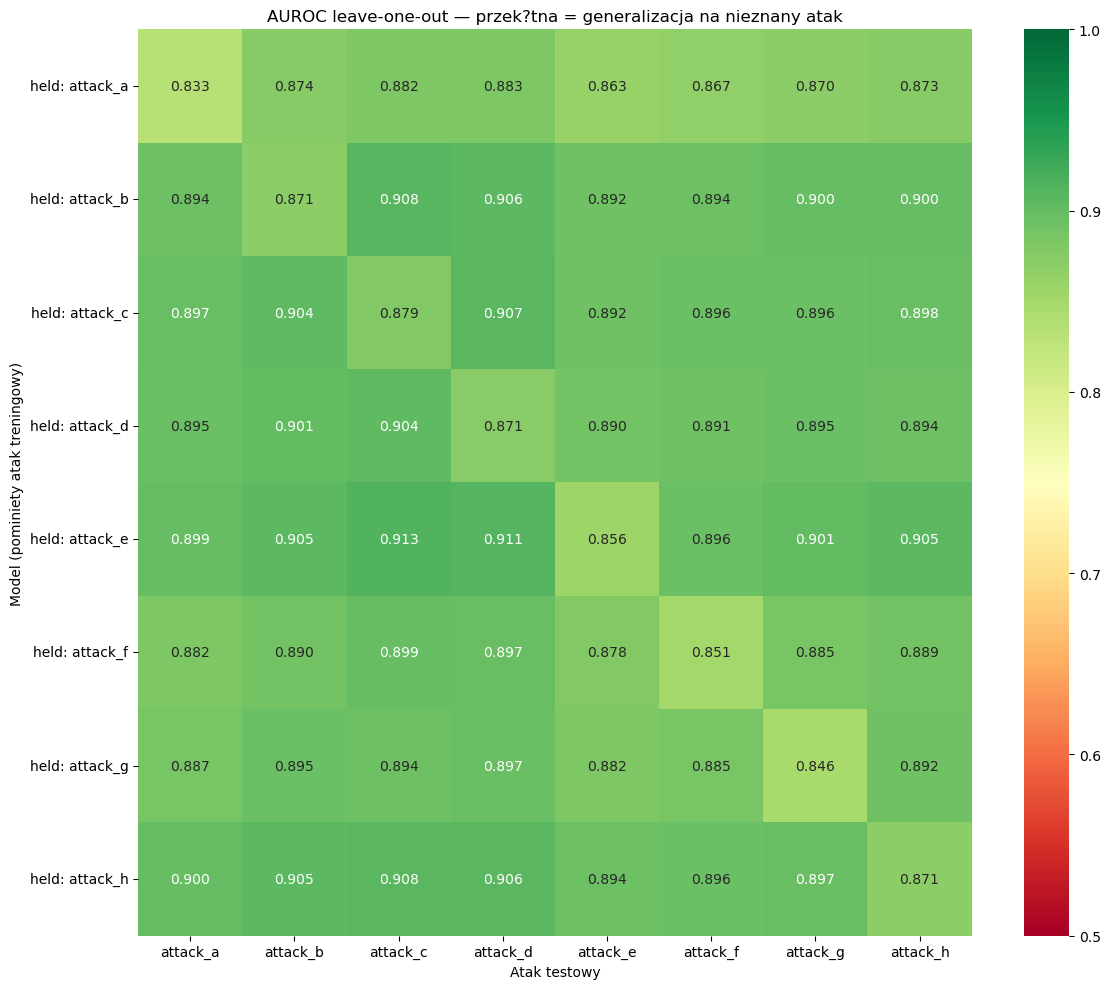

,attack_a,attack_b,attack_c,attack_d,attack_e,attack_f,attack_g,attack_h
held: attack_a,0.833,0.874,0.882,0.883,0.863,0.867,0.870,0.873
held: attack_b,0.894,0.871,0.908,0.906,0.892,0.894,0.900,0.900
held: attack_c,0.897,0.904,0.879,0.907,0.892,0.896,0.896,0.898
held: attack_d,0.895,0.901,0.904,0.871,0.890,0.891,0.895,0.894
held: attack_e,0.899,0.905,0.913,0.911,0.856,0.896,0.901,0.905
held: attack_f,0.882,0.890,0.899,0.897,0.878,0.851,0.885,0.889
held: attack_g,0.887,0.895,0.894,0.897,0.882,0.885,0.846,0.892
held: attack_h,0.900,0.905,0.908,0.906,0.894,0.896,0.897,0.871


In [12]:
# AUROC heatmap leave-one-out: held-out (wiersz) x atak testowy (kolumna)
# Przek?tna (i==j) = generalizacja na nieznany atak
n_attacks = len(ATTACK_NAMES)
auroc_matrix_loo = np.zeros((n_attacks, n_attacks))

for i, (held_out_name, model) in enumerate(mixed_clf_models.items()):
    model.eval()
    for j, test_attack_name in enumerate(ATTACK_NAMES):
        test_ds_j = ConcatDataset([clean_ds, attack_ds[test_attack_name]])
        test_loader = DataLoader(test_ds_j, batch_size=64, shuffle=False, num_workers=0)

        all_scores, all_labels = [], []
        with torch.no_grad():
            for imgs, is_poisoned in test_loader:
                imgs = imgs.to(model.device)
                scores = torch.sigmoid(model(imgs)).cpu()
                all_scores.extend(scores.numpy())
                all_labels.extend(is_poisoned.numpy())

        auroc_matrix_loo[i, j] = roc_auc_score(all_labels, all_scores)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    auroc_matrix_loo,
    annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=0.5, vmax=1.0,
    xticklabels=ATTACK_NAMES,
    yticklabels=[f'held: {n}' for n in ATTACK_NAMES],
    ax=ax
)
ax.set_xlabel('Atak testowy')
ax.set_ylabel('Model (pominiety atak treningowy)')
ax.set_title('AUROC leave-one-out — przek?tna = generalizacja na nieznany atak')
plt.tight_layout()
plt.show()

auroc_loo_df = pd.DataFrame(auroc_matrix_loo,
                             index=[f'held: {n}' for n in ATTACK_NAMES],
                             columns=ATTACK_NAMES)
display(auroc_loo_df.round(3))

In [15]:
import logging
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

mixed_clf_models = {}

for held_out in ATTACK_NAMES:
    train_attacks = [name for name in ATTACK_NAMES if name != held_out]
    print(f'\n--- Held out (unseen): {held_out}')

    # Polaczenie: clean + wszystkie ataki poza held_out
    for i in range(1, len(train_attacks)):
        mixed_ds = ConcatDataset([clean_ds] + [attack_ds[name] for name in train_attacks][:i])
        train_size = int(0.8 * len(mixed_ds))
        val_size   = len(mixed_ds) - train_size
        train_split, val_split = random_split(
            mixed_ds, [train_size, val_size],
            generator=torch.Generator().manual_seed(SEED)
        )

        train_loader = DataLoader(train_split, batch_size=64, shuffle=True,  num_workers=0)
        val_loader   = DataLoader(val_split,   batch_size=64, shuffle=False, num_workers=0)

        clf = LitAnomalyClassifier(encoder=copy.deepcopy(ae_model.encoder))
        trainer = pl.Trainer(
            max_epochs=10,
            accelerator='auto',
            devices=1,
            log_every_n_steps=10,
            enable_model_summary=False,
            enable_progress_bar=False,
            logger=False,
        )
        trainer.fit(clf, train_loader, val_loader)

        model.eval()
        test_ds_j = ConcatDataset([clean_ds, attack_ds[held_out]])
        test_loader = DataLoader(test_ds_j, batch_size=64, shuffle=False, num_workers=0)

        all_scores, all_labels = [], []
        with torch.no_grad():
            for imgs, is_poisoned in test_loader:
                imgs = imgs.to(model.device)
                scores = torch.sigmoid(model(imgs)).cpu()
                all_scores.extend(scores.numpy())
                all_labels.extend(is_poisoned.numpy())
        print("nieznany atak to: " + held_out )        

        print(f'Użyto pierwszych {i} ataków uzyskany AUROC: {roc_auc_score(all_labels, all_scores)}')


auroc_loo_df = pd.DataFrame(auroc_matrix_loo,
                             index=[f'held: {n}' for n in ATTACK_NAMES],
                             columns=ATTACK_NAMES)
display(auroc_loo_df.round(3))    


--- Held out (unseen): attack_a
nieznany atak to: attack_a
Użyto pierwszych 1 ataków uzyskany AUROC: 0.8995689999999998


c:\Users\woks0\anaconda3\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory c:\Users\woks0\OneDrive\Pulpit\INA\magisterka\machine_learning\anomaly\checkpoints exists and is not empty.
c:\Users\woks0\anaconda3\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\woks0\anaconda3\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
c:\Users\woks0\anaconda3\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `Da

nieznany atak to: attack_a
Użyto pierwszych 2 ataków uzyskany AUROC: 0.8995689999999998


c:\Users\woks0\anaconda3\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory c:\Users\woks0\OneDrive\Pulpit\INA\magisterka\machine_learning\anomaly\checkpoints exists and is not empty.
c:\Users\woks0\anaconda3\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\woks0\anaconda3\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
c:\Users\woks0\anaconda3\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `Da

nieznany atak to: attack_a
Użyto pierwszych 3 ataków uzyskany AUROC: 0.8995689999999998


...

c:\Users\woks0\anaconda3\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory c:\Users\woks0\OneDrive\Pulpit\INA\magisterka\machine_learning\anomaly\checkpoints exists and is not empty.
c:\Users\woks0\anaconda3\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\woks0\anaconda3\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
c:\Users\woks0\anaconda3\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `Da

nieznany atak to: attack_c
Użyto pierwszych 2 ataków uzyskany AUROC: 0.9075010000000001


c:\Users\woks0\anaconda3\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory c:\Users\woks0\OneDrive\Pulpit\INA\magisterka\machine_learning\anomaly\checkpoints exists and is not empty.
c:\Users\woks0\anaconda3\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\woks0\anaconda3\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
c:\Users\woks0\anaconda3\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `Da

SystemExit: 1

c:\Users\woks0\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
